In [1]:
pip install meteostat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


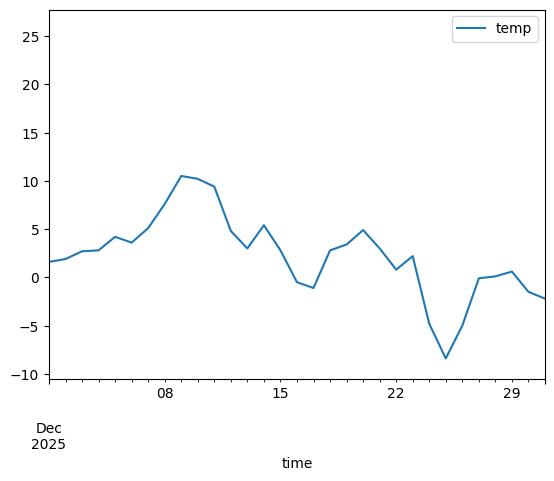

In [2]:
from datetime import date
import matplotlib.pyplot as plt
import meteostat as ms


# Specify location and time range
POINT = ms.Point(52.4064, 16.9252)  
START = date(2025, 1, 1)
END = date(2025, 12, 31)

# Get nearby weather stations
stations = ms.stations.nearby(POINT, limit=4)

# Get daily data & perform interpolation
#ts = ms.hourly(stations, START, END)
ts = ms.daily(stations, START, END)
# print(ts)

# interpolacja przestrzenna
df = ms.interpolate(ts, POINT).fetch()
df.to_csv("poznan_daily_2018_2025.csv", index=True, encoding="utf-8")

# Plot line chart including average, minimum and maximum temperature
# ax = df.plot(y=[ms.Parameter.TEMP, ms.Parameter.TMIN, ms.Parameter.TMAX])
ax = df.plot(y=[ms.Parameter.TEMP])
# ax.set_xlim("2018-01-01", "2020-12-31")
ax.set_xlim("2025-12-01", "2025-12-31")

plt.show()